In [8]:
import os
import sys
import numpy as np
import xarray as xr
import geopandas as gpd
import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [9]:
# product, time_reso = 'IMERG', '3h'
# product, time_reso = 'CMORPH', '3h'
# product, time_reso = 'MSWEP', '3h'
# product, time_reso = 'ERA5', '3h'
# product, time_reso = 'GSMaP', '3h'
product, time_reso = 'CHIRPS', '1dy'

In [10]:
dir_base = os.path.join('..','..','output','Beta')

In [11]:
data_dir = os.path.join(dir_base,f'VENETO_Beta_{product}_{time_reso}_2002_2023_npix_2.nc')
DATA = xr.open_dataset(data_dir)

lon2d, lat2d = np.meshgrid(DATA.lon.values, DATA.lat.values)
Beta = DATA.BETA.values

In [12]:
# PADOVA
# lon_min, lon_max, lat_min, lat_max, area = 11, 12.5, 45, 46, 'PADOVA'
# VENETO
lon_min, lon_max, lat_min, lat_max, area = 10.5, 13.5, 44.5, 47, 'VENETO'
# ITALY
# lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'

In [13]:
if area == 'PADOVA':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Padova.geojson'))
elif area == 'VENETO':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Veneto.geojson'))
elif area == 'ITALY':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Italy_simple.geojson'))
else:
    sys.exit("Area not recognized. Please choose 'VENETO' or 'ITALY'.")

GEOMETRY_union = GEOMETRY.unary_union

/tmp/ipykernel_55104/726573604.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  GEOMETRY_union = GEOMETRY.unary_union


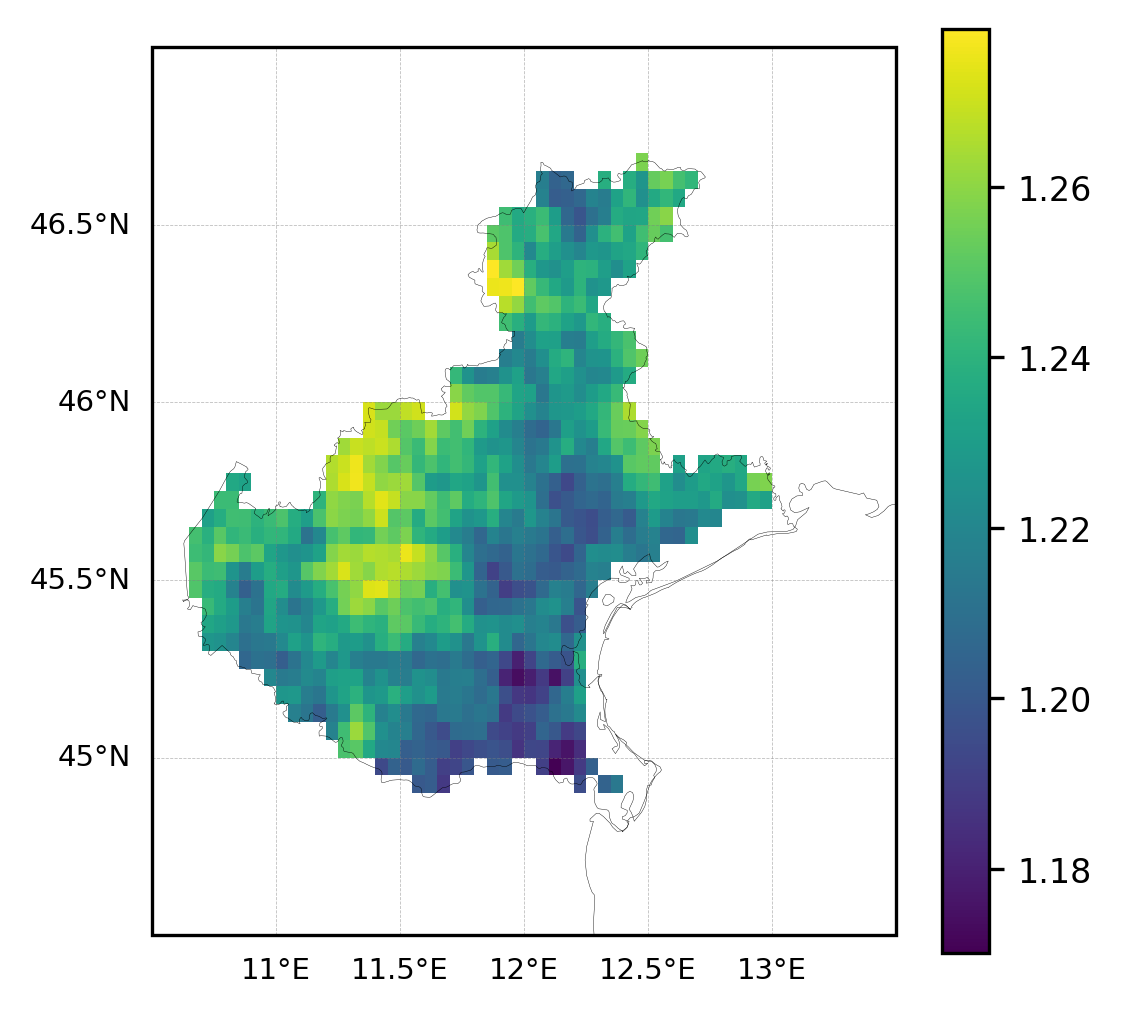

In [14]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(4,4),dpi=300)
gs = gridspec.GridSpec(1,1)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, Beta)
cbar = plt.colorbar(a1)
cbar.ax.tick_params(labelsize=8)

gl = ax1.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': 'k'}
gl.ylabel_style = {'size': 7, 'color': 'k'}